In [93]:
import os
import math
import glob
from typing import List, Tuple

from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Configs

In [79]:
DATA_DIR = "../data/0-7"     # put your PNGs here
PREDICT_DIR = "../data/8-E"
IMG_HEIGHT = 64              # fixed network height
IMG_WIDTH = 624
PAD_VALUE = 0.0              # background pad
BATCH_SIZE = 32
EPOCHS = 5
LR = 1e-3
DOWNSAMPLE = 4                   # width stride factor of the CNN (must match model)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [80]:
# max_w = 0
# for filename in os.listdir(DATA_DIR):

#     if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tiff", ".webp")):
#         path = os.path.join(DATA_DIR, filename)

#         with Image.open(path) as img:
#             w, h = img.size
#             max_w = max(w, max_w)
#             ratio = w / h
#             print(f"{filename}: {w}x{h}, aspect ratio = {ratio:.3f}")
# max_w

# Utils

In [81]:
def load_png(path: str, target_h: int = IMG_HEIGHT, target_w: int = IMG_WIDTH) -> np.ndarray:
    im = Image.open(path).convert("RGB")
    rgb = np.array(im)                          # RGB uint8
    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)  # OpenCV uses BGR
    
    # Build a mask of black/near-black pixels only.
    # Assume nothing else in image is black; tune threshold as needed.
    # Black criterion: max channel below threshold.
    threshold = 20  # increase to 30–40 if lines are anti-aliased
    mx = rgb.max(axis=2)
    mask = (mx < threshold).astype(np.uint8) * 255  # 0/255 mask
    
    # Optionally thin or slightly dilate mask to capture anti-aliased fringes
    # kernel = np.ones((3,3), np.uint8)
    # mask = cv2.dilate(mask, kernel, iterations=1)
    
    # Inpaint to remove black pixels/lines
    inpainted = cv2.inpaint(bgr, mask, inpaintRadius=3, flags=cv2.INPAINT_TELEA)
    
    # Convert back to PIL RGB and then to grayscale
    inpainted_rgb = cv2.cvtColor(inpainted, cv2.COLOR_BGR2RGB)
    pil_inpainted = Image.fromarray(inpainted_rgb)
    img = pil_inpainted.convert("L")
    
    # grayscale, keep aspect, resize to fixed height
    # img = Image.open(path).convert("L")
    w, h = img.size
    new_w = max(1, int(round(w * (target_h / float(h)))))
    img = img.resize((new_w, target_h), Image.BILINEAR)

    if new_w < target_w:
        pad_left = (target_w - new_w) // 2
        pad_right = target_w - new_w - pad_left
        img = ImageOps.expand(img, border=(pad_left, 0, pad_right, 0), fill=255)

    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = (arr - 0.5) / 0.5  # normalize to roughly [-1, 1]
    return arr  # H x W

def filename_to_label(path: str) -> str:
    base = os.path.basename(path)
    name, _ = os.path.splitext(base)
    return name.split("-")[0]

def build_charset(paths: List[str]) -> List[str]:
    chars = set()
    for p in paths:
        for ch in filename_to_label(p):
            chars.add(ch)
    return sorted(list(chars))

def encode_label(text: str, char_to_idx: dict, blank_idx: int) -> List[int]:
    # map text to indices; blank is not used in targets
    # print([ch for ch in text])
    return [char_to_idx[ch] for ch in text]

def pad_batch(images: List[np.ndarray], pad_val: float = PAD_VALUE) -> Tuple[torch.Tensor, List[int]]:
    # images: list of HxW arrays, same H, variable W
    H = images[0].shape[0]
    widths = [im.shape[1] for im in images]
    max_w = max(widths)
    batch = np.full((len(images), 1, H, max_w), pad_val, dtype=np.float32)
    for i, im in enumerate(images):
        w = im.shape[1]
        batch[i, 0, :, :w] = im
    return torch.from_numpy(batch), widths

# Dataset

In [82]:
class CaptchaDataset(Dataset):
    def __init__(self, root_dir: str, charset: List[str] = None, provided_paths: List[str] = None):
        self.paths = provided_paths if provided_paths is not None else sorted(glob.glob(os.path.join(root_dir, "*.png")))
        if not self.paths:
            raise RuntimeError(f"No PNGs found in {root_dir}")
        self.charset = build_charset(self.paths) if charset is None else charset
        # Reserve index 0 for CTC blank
        self.blank_idx = 0
        self.char_to_idx = {c: i + 1 for i, c in enumerate(self.charset)}  # 1..C
        self.idx_to_char = {i + 1: c for i, c in enumerate(self.charset)}   # no mapping for 0 (blank)


    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        img = load_png(p, IMG_HEIGHT)  # H x W
        label_str = filename_to_label(p)
        targets = encode_label(label_str, self.char_to_idx, self.blank_idx)
        
        img = img.reshape((1, IMG_HEIGHT, IMG_WIDTH))
        img = (img / 127.5) - 1.0
        img = torch.FloatTensor(img)
        
        target_length = [len(targets)]
        target = torch.LongTensor(targets)
        target_length = torch.LongTensor(target_length)
        return img, target, target_length
        # return img, torch.tensor(targets, dtype=torch.long)

# def collate_fn(batch, downsample: int = DOWNSAMPLE, pad_val: float = PAD_VALUE):
#     imgs, targets_list, _ = zip(*batch)
#     batch_img, widths = pad_batch(list(imgs), pad_val)
#     # Compute input lengths after CNN downsampling (T per sample)
#     input_lengths = [max(1, w // downsample) for w in widths]
#     # Concatenate targets for CTCLoss
#     targets = torch.cat(targets_list)
#     target_lengths = [len(t) for t in targets_list]
#     return batch_img, targets, torch.tensor(input_lengths, dtype=torch.long), torch.tensor(target_lengths, dtype=torch.long)

def collate_fn(batch):
    images, targets, target_lengths = zip(*batch)
    images = torch.stack(images, 0)
    targets = torch.cat(targets, 0)
    target_lengths = torch.cat(target_lengths, 0)
    return images, targets, target_lengths


# Model

In [83]:
class CRNN(nn.Module):

    def __init__(self, img_channel, img_height, img_width, num_class,
                 map_to_seq_hidden=64, rnn_hidden=256, leaky_relu=False):
        super(CRNN, self).__init__()

        self.cnn, (output_channel, output_height, output_width) = \
            self._cnn_backbone(img_channel, img_height, img_width, leaky_relu)

        self.map_to_seq = nn.Linear(output_channel * output_height, map_to_seq_hidden)

        self.rnn1 = nn.LSTM(map_to_seq_hidden, rnn_hidden, bidirectional=True)
        self.rnn2 = nn.LSTM(2 * rnn_hidden, rnn_hidden, bidirectional=True)

        self.dense = nn.Linear(2 * rnn_hidden, num_class)

    def _cnn_backbone(self, img_channel, img_height, img_width, leaky_relu):
        assert img_height % 16 == 0
        assert img_width % 4 == 0

        channels = [img_channel, 64, 128, 256, 256, 512, 512, 512]
        kernel_sizes = [3, 3, 3, 3, 3, 3, 2]
        strides = [1, 1, 1, 1, 1, 1, 1]
        paddings = [1, 1, 1, 1, 1, 1, 0]

        cnn = nn.Sequential()

        def conv_relu(i, batch_norm=False):
            # shape of input: (batch, input_channel, height, width)
            input_channel = channels[i]
            output_channel = channels[i+1]

            cnn.add_module(
                f'conv{i}',
                nn.Conv2d(input_channel, output_channel, kernel_sizes[i], strides[i], paddings[i])
            )

            if batch_norm:
                cnn.add_module(f'batchnorm{i}', nn.BatchNorm2d(output_channel))

            relu = nn.LeakyReLU(0.2, inplace=True) if leaky_relu else nn.ReLU(inplace=True)
            cnn.add_module(f'relu{i}', relu)

        # size of image: (channel, height, width) = (img_channel, img_height, img_width)
        conv_relu(0)
        cnn.add_module('pooling0', nn.MaxPool2d(kernel_size=2, stride=2))
        # (64, img_height // 2, img_width // 2)

        conv_relu(1)
        cnn.add_module('pooling1', nn.MaxPool2d(kernel_size=2, stride=2))
        # (128, img_height // 4, img_width // 4)

        # conv_relu(2)
        # conv_relu(3)
        # cnn.add_module(
        #     'pooling2',
        #     nn.MaxPool2d(kernel_size=(2, 1))
        # )  # (256, img_height // 8, img_width // 4)

        # conv_relu(4, batch_norm=True)
        # conv_relu(5, batch_norm=True)
        # cnn.add_module(
        #     'pooling3',
        #     nn.MaxPool2d(kernel_size=(2, 1))
        # )  # (512, img_height // 16, img_width // 4)

        # conv_relu(6)  # (512, img_height // 16 - 1, img_width // 4 - 1)

        # output_channel, output_height, output_width = \
        #     channels[-1], img_height // 16 - 1, img_width // 4 - 1
        output_channel, output_height, output_width = \
            channels[2], img_height // 4, img_width // 4
        return cnn, (output_channel, output_height, output_width)

    def forward(self, images):
        # shape of images: (batch, channel, height, width)

        conv = self.cnn(images)
        batch, channel, height, width = conv.size()

        conv = conv.view(batch, channel * height, width)
        conv = conv.permute(2, 0, 1)  # (width, batch, feature)
        
        seq = self.map_to_seq(conv)

        recurrent, _ = self.rnn1(seq)
        recurrent, _ = self.rnn2(recurrent)

        output = self.dense(recurrent)
        return output  # shape: (seq_len, batch, num_class)

# Decoder

In [103]:
# def ctc_greedy_decode(log_probs: torch.Tensor, blank_idx: int) -> List[str]:
#     labels = np.argmax(emission_log_prob, axis=-1)
    
#     new_labels = []
#     # merge same labels
#     previous = None
#     for l in labels:
#         if l != previous:
#             new_labels.append(l)
#             previous = l
#     # delete blank
#     new_labels = [l for l in new_labels if l != blank_idx]
    
#     return new_labels

from collections import defaultdict

import torch
import numpy as np
from scipy.special import logsumexp  # log(p1 + p2) = logsumexp([log_p1, log_p2])

NINF = -1 * float('inf')
DEFAULT_EMISSION_THRESHOLD = 0.01


def _reconstruct(labels, blank=0):
    new_labels = []
    # merge same labels
    previous = None
    for l in labels:
        if l != previous:
            new_labels.append(l)
            previous = l
    # delete blank
    new_labels = [l for l in new_labels if l != blank]

    return new_labels


def greedy_decode(emission_log_prob, blank=0, **kwargs):
    labels = np.argmax(emission_log_prob, axis=-1)
    print(labels)
    labels = _reconstruct(labels, blank=blank)
    return labels


def beam_search_decode(emission_log_prob, blank=0, **kwargs):
    beam_size = kwargs['beam_size']
    emission_threshold = kwargs.get('emission_threshold', np.log(DEFAULT_EMISSION_THRESHOLD))

    length, class_count = emission_log_prob.shape

    beams = [([], 0)]  # (prefix, accumulated_log_prob)
    for t in range(length):
        new_beams = []
        for prefix, accumulated_log_prob in beams:
            for c in range(class_count):
                log_prob = emission_log_prob[t, c]
                if log_prob < emission_threshold:
                    continue
                new_prefix = prefix + [c]
                # log(p1 * p2) = log_p1 + log_p2
                new_accu_log_prob = accumulated_log_prob + log_prob
                new_beams.append((new_prefix, new_accu_log_prob))

        # sorted by accumulated_log_prob
        new_beams.sort(key=lambda x: x[1], reverse=True)
        beams = new_beams[:beam_size]

    # sum up beams to produce labels
    total_accu_log_prob = {}
    for prefix, accu_log_prob in beams:
        labels = tuple(_reconstruct(prefix, blank))
        # log(p1 + p2) = logsumexp([log_p1, log_p2])
        total_accu_log_prob[labels] = \
            logsumexp([accu_log_prob, total_accu_log_prob.get(labels, NINF)])

    labels_beams = [(list(labels), accu_log_prob)
                    for labels, accu_log_prob in total_accu_log_prob.items()]
    labels_beams.sort(key=lambda x: x[1], reverse=True)
    labels = labels_beams[0][0]

    return labels


def prefix_beam_decode(emission_log_prob, blank=0, **kwargs):
    beam_size = kwargs['beam_size']
    emission_threshold = kwargs.get('emission_threshold', np.log(DEFAULT_EMISSION_THRESHOLD))

    length, class_count = emission_log_prob.shape

    beams = [(tuple(), (0, NINF))]  # (prefix, (blank_log_prob, non_blank_log_prob))
    # initial of beams: (empty_str, (log(1.0), log(0.0)))

    for t in range(length):
        new_beams_dict = defaultdict(lambda: (NINF, NINF))  # log(0.0) = NINF

        for prefix, (lp_b, lp_nb) in beams:
            for c in range(class_count):
                log_prob = emission_log_prob[t, c]
                if log_prob < emission_threshold:
                    continue

                end_t = prefix[-1] if prefix else None

                # if new_prefix == prefix
                new_lp_b, new_lp_nb = new_beams_dict[prefix]

                if c == blank:
                    new_beams_dict[prefix] = (
                        logsumexp([new_lp_b, lp_b + log_prob, lp_nb + log_prob]),
                        new_lp_nb
                    )
                    continue
                if c == end_t:
                    new_beams_dict[prefix] = (
                        new_lp_b,
                        logsumexp([new_lp_nb, lp_nb + log_prob])
                    )

                # if new_prefix == prefix + (c,)
                new_prefix = prefix + (c,)
                new_lp_b, new_lp_nb = new_beams_dict[new_prefix]

                if c != end_t:
                    new_beams_dict[new_prefix] = (
                        new_lp_b,
                        logsumexp([new_lp_nb, lp_b + log_prob, lp_nb + log_prob])
                    )
                else:
                    new_beams_dict[new_prefix] = (
                        new_lp_b,
                        logsumexp([new_lp_nb, lp_b + log_prob])
                    )

        # sorted by log(blank_prob + non_blank_prob)
        beams = sorted(new_beams_dict.items(), key=lambda x: logsumexp(x[1]), reverse=True)
        beams = beams[:beam_size]

    labels = list(beams[0][0])
    return labels


def ctc_decode(log_probs, label2char=None, blank=0, method='beam_search', beam_size=10):
    emission_log_probs = np.transpose(log_probs.cpu().numpy(), (1, 0, 2))
    # size of emission_log_probs: (batch, length, class)

    decoders = {
        'greedy': greedy_decode,
        'beam_search': beam_search_decode,
        'prefix_beam_search': prefix_beam_decode,
    }
    decoder = decoders[method]

    decoded_list = []
    for emission_log_prob in emission_log_probs:
        decoded = decoder(emission_log_prob, blank=blank, beam_size=beam_size)
        print(decoded)
        if label2char:
            decoded = [label2char[l] for l in decoded]
        decoded_list.append(decoded)
    return decoded_list

In [85]:
@torch.no_grad()
def predict(crnn, dataloader, label2char, decode_method, beam_size):
    crnn.eval()

    all_preds = []
    for batch_img, targets, input_lengths in loader:
        batch_img = batch_img.to(DEVICE)
        logits = crnn(batch_img)
        log_probs = torch.nn.functional.log_softmax(logits, dim=2)
    
        preds = ctc_decode(log_probs, method=decode_method, beam_size=beam_size,
                           label2char=label2char)
        all_preds += preds
        break

    return all_preds


def show_result(paths, preds):
    print('\n===== result =====')
    for path, pred in zip(paths, preds):
        text = ''.join(pred)
        print(f'{path} > {text}')

# Training

In [86]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    for batch_img, targets, input_lengths, target_lengths in loader:
        batch_img = batch_img.to(device)
        targets = targets.to(device)
        input_lengths = input_lengths.to(device)
        target_lengths = target_lengths.to(device)

        optimizer.zero_grad()
        log_probs = model(batch_img)  # T x B x C
        loss = criterion(log_probs, targets, input_lengths, target_lengths)
        loss.backward()
        optimizer.step()
        total += float(loss.item())
    return total / max(1, len(loader))


def train_batch(crnn, data, optimizer, criterion, device):
    crnn.train()
    images, targets, target_lengths = [d.to(device) for d in data]

    logits = crnn(images)
    log_probs = torch.nn.functional.log_softmax(logits, dim=2)

    batch_size = images.size(0)
    input_lengths = torch.LongTensor([logits.size(0)] * batch_size)
    target_lengths = torch.flatten(target_lengths)

    loss = criterion(log_probs, targets, input_lengths, target_lengths)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(crnn.parameters(), 5) # gradient clipping with 5
    optimizer.step()
    return loss.item()

@torch.no_grad()
def infer_paths(model, paths: List[str], ds_proto: CaptchaDataset, device):
    model.eval()
    batch_imgs = [load_png(p, IMG_HEIGHT) for p in paths]
    batch_img_t, widths = pad_batch(batch_imgs, PAD_VALUE)
    input_lengths = torch.tensor([max(1, w // DOWNSAMPLE) for w in widths], dtype=torch.long)
    log_probs = model(batch_img_t.to(device))
    print(log_probs)
    preds = ctc_greedy_decode(log_probs, input_lengths.tolist(), ds_proto.blank_idx, ds_proto.idx_to_char)
    return preds

In [87]:
# Collect data paths and charset
all_pngs = sorted(glob.glob(os.path.join(DATA_DIR, "*.png")))
dataset = CaptchaDataset(DATA_DIR)
num_classes = 1 + len(dataset.charset)  # include blank at 0

# DataLoader
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                    collate_fn=collate_fn)

In [97]:
# Model, loss, optim
model = CRNN(1, IMG_HEIGHT, IMG_WIDTH, num_classes).to(DEVICE)
# criterion = nn.CTCLoss(blank=dataset.blank_idx, reduction="mean", zero_infinity=True)  # safer training
# optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
optimizer = optim.RMSprop(model.parameters(), lr=LR)
criterion = nn.CTCLoss(reduction='sum', zero_infinity=True)

In [101]:
# for epoch in range(1, 2):
#     avg_loss = train(model, loader, optimizer, criterion, DEVICE)
#     print(f"Epoch {epoch}: loss={avg_loss:.4f}")
# i = 1
show_interval = 16
for epoch in range(1, EPOCHS+1):
    print(f'epoch: {epoch}')
    tot_train_loss = 0.
    tot_train_count = 0
    for i, train_data in enumerate(loader):
        loss = train_batch(model, train_data, optimizer, criterion, DEVICE)
        train_size = train_data[0].size(0)

        tot_train_loss += loss
        tot_train_count += train_size
        if i % show_interval == 0:
            print('train_batch_loss[', i, ']: ', loss / train_size)

        # if i % valid_interval == 0:
        #     evaluation = evaluate(crnn, valid_loader, criterion,
        #                           decode_method=config['decode_method'],
        #                           beam_size=config['beam_size'])
        #     print('valid_evaluation: loss={loss}, acc={acc}'.format(**evaluation))

        #     if i % save_interval == 0:
        #         prefix = 'crnn'
        #         loss = evaluation['loss']
        #         save_model_path = os.path.join(config['checkpoints_dir'],
        #                                        f'{prefix}_{i:06}_loss{loss}.pt')
        #         torch.save(crnn.state_dict(), save_model_path)
        #         print('save model at ', save_model_path)

        # i += 1

    print('train_loss: ', tot_train_loss / tot_train_count)

epoch: 1
train_batch_loss[ 0 ]:  22.064590454101562
train_batch_loss[ 16 ]:  22.26927947998047
train_batch_loss[ 32 ]:  22.68486785888672
train_loss:  22.607734364911543
epoch: 2
train_batch_loss[ 0 ]:  21.373695373535156
train_batch_loss[ 16 ]:  21.96350860595703
train_batch_loss[ 32 ]:  21.18195343017578
train_loss:  22.185103083839103
epoch: 3
train_batch_loss[ 0 ]:  22.86617660522461
train_batch_loss[ 16 ]:  20.880802154541016
train_batch_loss[ 32 ]:  21.772476196289062
train_loss:  22.10211201817536
epoch: 4
train_batch_loss[ 0 ]:  21.895431518554688
train_batch_loss[ 16 ]:  21.425609588623047
train_batch_loss[ 32 ]:  21.693016052246094
train_loss:  22.05815212785705
epoch: 5
train_batch_loss[ 0 ]:  20.900253295898438
train_batch_loss[ 16 ]:  23.2305965423584
train_batch_loss[ 32 ]:  21.07138442993164
train_loss:  21.990292333177297


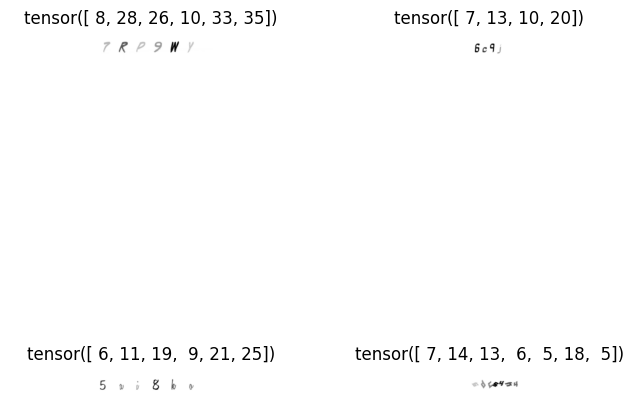

In [99]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 2,2
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(dataset), size=(1,)).item()
    img, label, p = dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(f"{label}")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [77]:
# # Quick smoke test on a few samples
# print(num_classes)
# test_paths = all_pngs[:8]
# preds = predict(model, test_paths, dataset, DEVICE)
# for p, y in zip(test_paths, preds):
#     print(os.path.basename(p), "->", y)

In [104]:
predict_dataset = CaptchaDataset(PREDICT_DIR)

predict_loader = DataLoader(predict_dataset, batch_size=BATCH_SIZE, shuffle=False,
                    collate_fn=collate_fn)

preds = predict(model, predict_loader, predict_dataset.idx_to_char,
                decode_method="beam_search",
                beam_size=5)
all_pngs = sorted(glob.glob(os.path.join(PREDICT_DIR, "*.png")))
show_result(all_pngs, preds)

[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]
[8]

===== result =====
../data/8-E/80a79g-0.png > 7
../data/8-E/80cidz2u-0.png > 7
../data/8-E/80cmz27f-0.png > 7
../data/8-E/80qxfez1-0.png > 7
../data/8-E/80v0-0.png > 7
../data/8-E/8148-0.png > 7
../data/8-E/8173pa-0.png > 7
../data/8-E/81g25kx-0.png > 7
../data/8-E/81jvmge-0.png > 7
../data/8-E/81x9da4a-0.png > 7
../data/8-E/82277th-0.png > 7
../data/8-E/82gu-0.png > 7
../data/8-E/82h3z-0.png > 7
../data/8-E/82ky-0.png > 7
../data/8-E/82nr-0.png > 7
../data/8-E/82te98w3-0.png > 7
../data/8-E/82tt8k5m-0.png > 7
../data/8-E/82vxl6vy-0.png > 7
../data/8-E/838n-0.png > 7
../data/8-E/839cg-0.png > 7
../data/8-E/83f6o-0.png > 7
../data/8-E/8466mwt-0.png > 7
../data/8-E/84g5oe-0.png > 7
../data/8-E/84gq-0.png > 7
../data/8-E/84rdopne-0.png > 7
../data/8-E/84we-0.png > 7
../data/8-E/84wlitw-0.png > 7
../data/8-E/853n-0.png > 7
../data/8-E/854d4-0.png > 7
../data/8-E/